In [1]:
# 1: Package Installation & Setup

In [2]:
!pip install numpy pandas scikit-learn matplotlib seaborn xgboost

In [3]:
# 2: Library Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Pipeline & Preprocessing Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
# 3: Data Loading & Exploratory Data Analysis (EDA)

In [6]:
df = pd.read_csv('heart.csv')

# Display basic dataset details
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("--- Sample Data ---")
display(df.head())

--- Dataset Shape ---
Rows: 1025, Columns: 14


--- Missing Values Check ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
--- Sample Data ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
# 4: Feature Separation & Train-Test Split

In [8]:
X = df.drop(columns=['target'])
y = df['target']

# Split into 80% Training data and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (820, 13)
Testing features shape: (205, 13)


In [9]:
# 5: Pipeline Building & Model Training

In [10]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Apply StandardScaler only to the numerical features to keep values on the same scale
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough' # Keep categorical features as they are (already encoded in this dataset)
)

# Combine preprocessing and Random Forest Classifier into a single secure pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5))
])

# Train the complete pipeline
model_pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!")

Pipeline trained successfully!


In [11]:
# 6: Model Evaluation & Metrics Export

=== CONFUSION MATRIX ===
[[ 91   9]
 [  5 100]]

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       100
           1       0.92      0.95      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



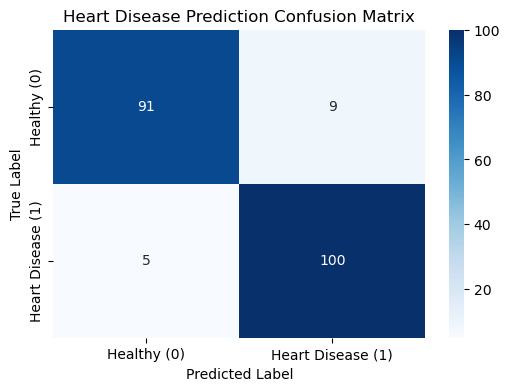

In [12]:
y_pred = model_pipeline.predict(X_test)

# Output performance metrics
print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix visually
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy (0)', 'Heart Disease (1)'], 
            yticklabels=['Healthy (0)', 'Heart Disease (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Heart Disease Prediction Confusion Matrix')
plt.show()

In [13]:
# Create a dummy patient profile to test the pipeline's real-time prediction
# Features must match the exact columns of your original X DataFrame
custom_patient_data = pd.DataFrame([{
    'age': 58,
    'sex': 1,
    'cp': 2,          # Chest pain type
    'trestbps': 140,  # Resting blood pressure
    'chol': 260,      # Cholesterol level
    'fbs': 0,         # Fasting blood sugar
    'restecg': 1,
    'thalach': 125,   # Maximum heart rate achieved
    'exang': 1,
    'oldpeak': 2.8,   # ST depression
    'slope': 1,
    'ca': 0,
    'thal': 3
}])

# Extract the predicted probability and label from the trained pipeline
probability = model_pipeline.predict_proba(custom_patient_data)[0][1] * 100
predicted_label = model_pipeline.predict(custom_patient_data)[0]

print("=== Real-Time Sandbox Validation ===")
print(f"Custom Patient Input Preview: Age {custom_patient_data['age'].values[0]}, Cholesterol {custom_patient_data['chol'].values[0]}")
print(f"Model Confidence Score: {probability:.2f}%")
print(f"Predicted Output: Label_{predicted_label} ('Heart Disease Detected' if 1 else 'Normal/Healthy')")

=== Real-Time Sandbox Validation ===
Custom Patient Input Preview: Age 58, Cholesterol 260
Model Confidence Score: 24.29%
Predicted Output: Label_0 ('Heart Disease Detected' if 1 else 'Normal/Healthy')


In [14]:
import joblib

# Serialize and save the entire trained pipeline object (preprocessor + model)
# This creates a single, deployment-ready asset file
model_filename = 'heart_disease_prediction_pipeline.joblib'
joblib.dump(model_pipeline, model_filename)

print(f"Success! Complete pipeline asset successfully compiled and saved as: '{model_filename}'")

Success! Complete pipeline asset successfully compiled and saved as: 'heart_disease_prediction_pipeline.joblib'
